# Encoding Numerical Feature 
Sometimes we need our numerical data to be categorical for easy and better ussage. That's why we need Numerical Encoding Feature.
`There are two ways to do that`
- Discretization or Binning
- Binarization

## Discretization
Discretization is the process of transforming continuous variables into discrete variables by creating a set of contiguous intervals that span the range of the variable's values. Discretization is alos called binning,where bin is an alternative name for interval.

`Why us Discretization:`
- To handle Outliers
- To improve the value spread

### Types Of Discretization
1. Unsupervised  
    Sklearn method used for this is KBinsDiscretized(bins,strategy)
   1. Equal Width(Uniform) 
        In This binning method the data is divided into equal parts. like suppose if there is an age column from 0 to 100 and the numbers of bins defined is 10 then each `bin = max-min/no.of bins`.

        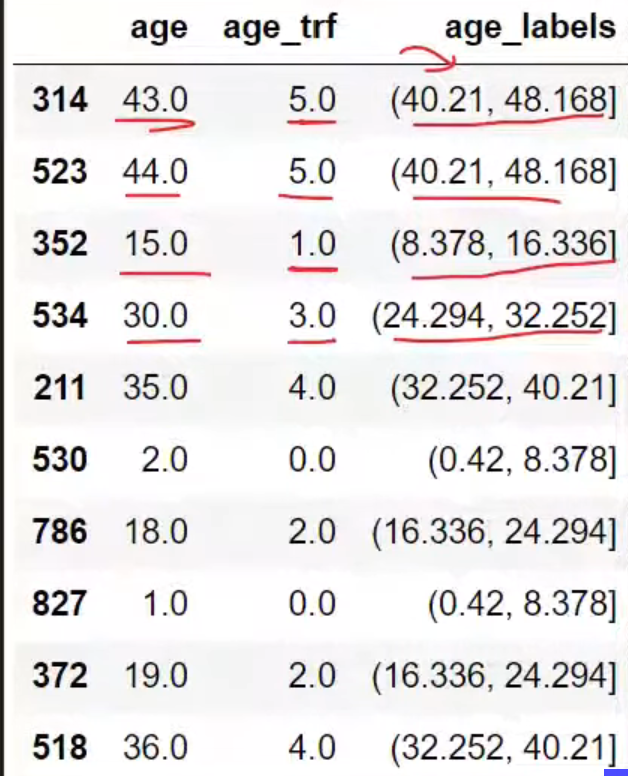

   2. Equal Frequency(Quantile)
        In this binning method the data is divided as the quantile of the total observation.
        Each part will have equal number of quantities.

        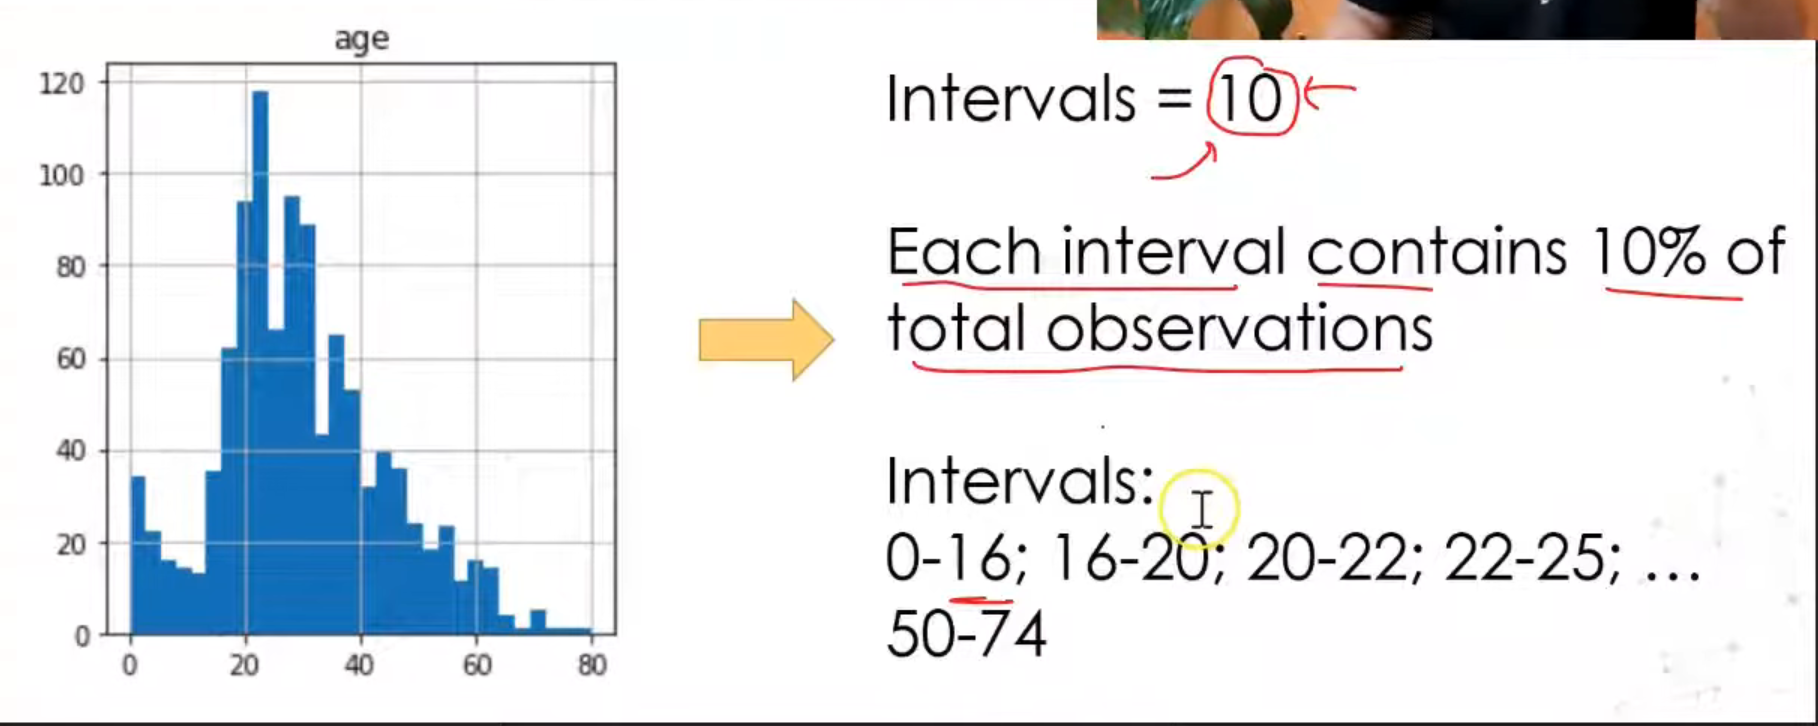

   3. Kmeans
        Here the number of clusters is defined by us and then the data is divided into those number of clusters and all the observations which are closests to their respective cluster points will likely to be in that cluster.

        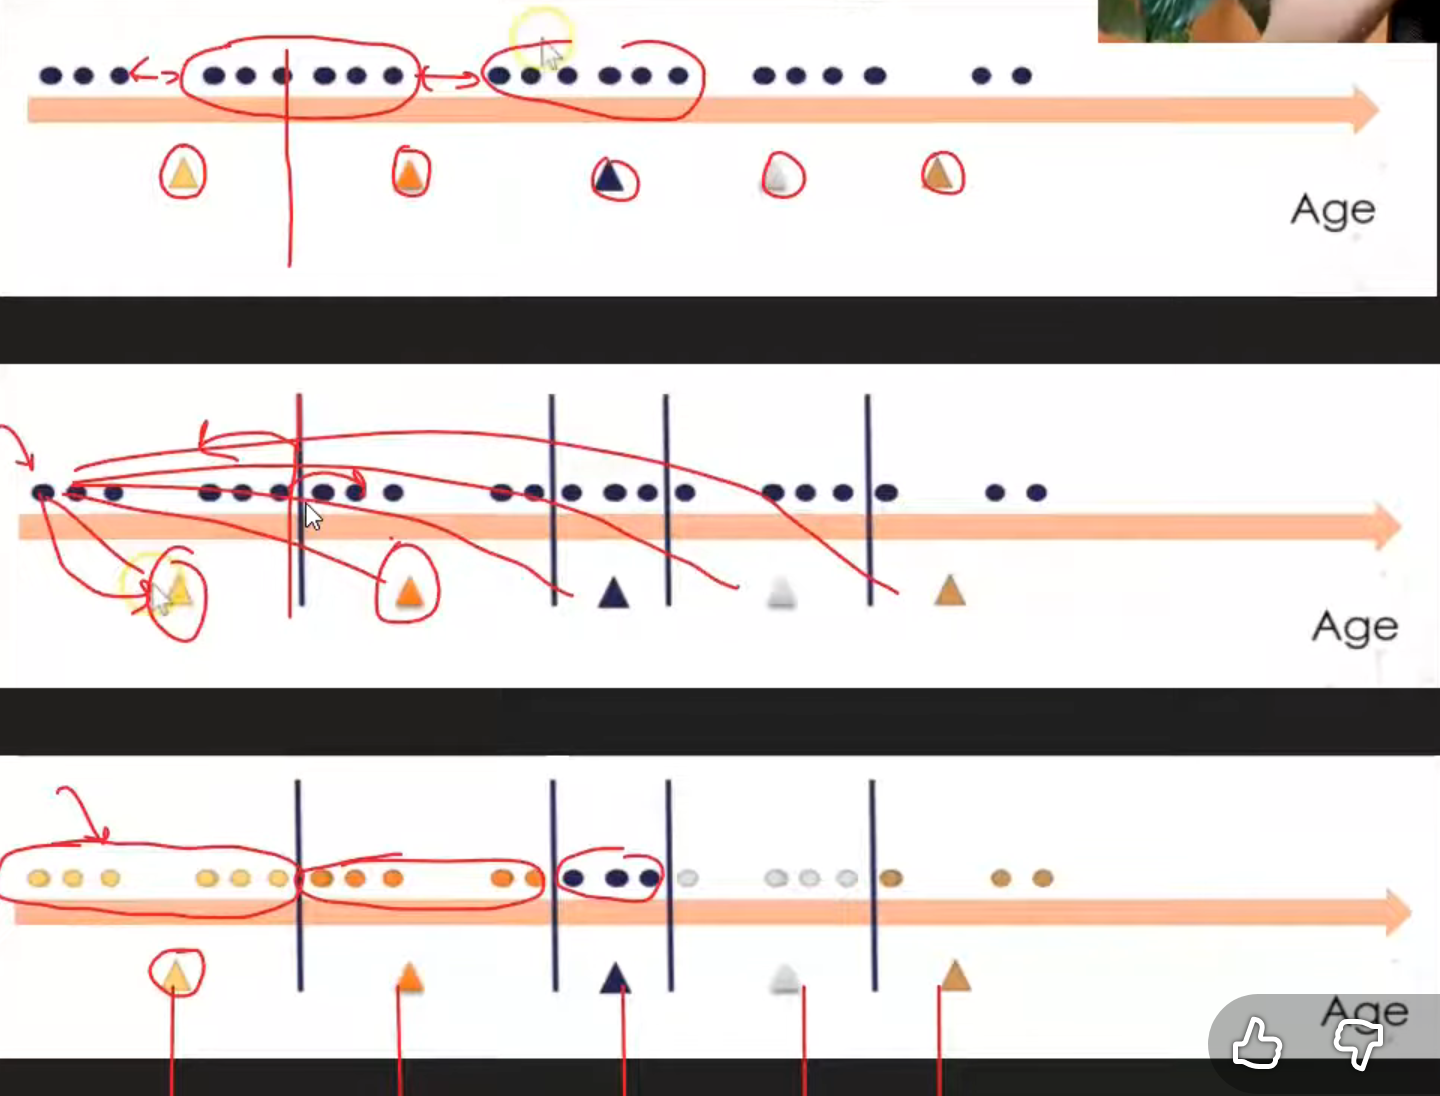

2. SuperVised 
   1. DecisionTree Binning
   
3. Custom Binning 
    In this data is divided into custom bins like age is divided into kids(0-18),Adults(18-60),old(60 above).
    Here the data is divided into three categories with no equal size.There is no built-in method for this and we have make the logic on ourselves.

In [97]:
import pandas as pd 
import numpy as np

In [98]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [99]:
df = pd.read_csv('E:\\WORK\\AI-ML\\data\\titanic.csv',usecols=['Age','Fare','Survived'])

In [100]:
df.head()

,Survived,Age,Fare
0,0,34.5,7.8292
1,1,47.0,7.0000
2,0,62.0,9.6875
3,0,27.0,8.6625
4,1,22.0,12.2875


In [101]:
df.shape

(418, 3)

In [102]:
df.dropna(inplace=True)

In [103]:
df.shape


(331, 3)

In [104]:
X=df.iloc[:,1:]
y=df.iloc[:,0]

In [105]:
X_train,X_test,y_train,y_test =train_test_split(X,y,test_size=0.2,random_state=42)

In [106]:
X_train.head(2)

,Age,Fare
281,0.75,13.775
96,76.00,78.850


In [107]:
clf=DecisionTreeClassifier()

In [108]:
clf.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [109]:
y_pred =clf.predict(X_test)

In [110]:
accuracy_score(y_test,y_pred)

0.5671641791044776

In [111]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.5711229946524063)

In [112]:
kbin_age =KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare =KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [113]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [114]:
X_train_trf=trf.fit_transform(X_train)
X_test_trf=trf.transform(X_test)

e:\WORK\AI-ML\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
e:\WORK\AI-ML\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


## What these two lines do

These two lines apply the preprocessing transformation to the training and test data:

```python
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)
```

### 1. `fit_transform(X_train)`
- `fit` means: learn the rules from the training data.
- `transform` means: apply those rules to change the data.
- So `fit_transform` does both steps together.

### 2. `transform(X_test)`
- This applies the same rules learned from training data to the test data.
- It is important to use the same transformation for test data.

### Why do we do this?
- The training data is used to learn how to bin the values.
- The test data is then converted in the same way.
- This helps the model see both sets of data in a consistent format.

### In simple words
- `X_train_trf` = transformed training data
- `X_test_trf` = transformed test data

So the model trains and tests on processed data, not the raw original values.


In [115]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.33      , 13.53333333, 18.        , 20.        , 22.        ,
              24.        , 25.2       , 27.73333333, 30.        , 32.        ,
              36.        , 39.        , 43.8       , 47.93333333, 55.        ,
              76.        ])                                                   ],
      dtype=object)

In [116]:
trf.named_transformers_['second'].bin_edges_

array([array([  0.        ,   7.42554   ,   7.77805333,   7.8958    ,
                8.6625    ,  12.25276667,  13.        ,  14.89108667,
               21.        ,  26.        ,  27.7208    ,  39.        ,
               58.41      ,  78.67944667, 141.32528   , 512.3292    ])],
      dtype=object)

In [117]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [121]:
output['age_labels'] = pd.cut(
    x=X_train['Age'],
    bins=trf.named_transformers_['first'].bin_edges_[0].tolist()
)

output['fare_labels'] = pd.cut(
    x=X_train['Fare'],
    bins=trf.named_transformers_['second'].bin_edges_[0].tolist()
)

## What `pd.cut()` is doing

These lines create category labels for the binned values:

```python
output['age_labels'] = pd.cut(
    x=X_train['Age'],
    bins=trf.named_transformers_['first'].bin_edges_[0].tolist()
)

output['fare_labels'] = pd.cut(
    x=X_train['Fare'],
    bins=trf.named_transformers_['second'].bin_edges_[0].tolist()
)
```

### What is `pd.cut()`?
`pd.cut()` is used to split a continuous numeric column into intervals (bins) and assign labels to each interval.

### In simple words
- It takes a numeric column like `Age` or `Fare`
- It puts values into ranges or buckets
- It gives each bucket a label

### Why is it used here?
After binning, we want to see which interval each value belongs to.
So instead of only seeing the transformed numeric bin number, we also create readable labels.

### Example
If `Age` values are split into ranges like:
- `0-10`
- `10-20`
- `20-30`

then `pd.cut()` will place each age into one of these groups.

### Important parts
- `x=`: the column we want to group
- `bins=`: the boundary values that define the ranges

So this step helps us understand the binning result in a more human-readable way.



This expression:

```python
trf.named_transformers_['first'].bin_edges_[0].tolist()
```

means:

- `trf` = the ColumnTransformer object
- `named_transformers_` = a dictionary inside it that stores each transformer by name
- `['first']` = the first transformer you created
- `.bin_edges_` = the bin edge values learned by that transformer
- `[0]` = take the first set of bin edges
- `.tolist()` = convert those values from a NumPy array into a Python list

So in simple words:
- it gets the cut points/boundaries used to divide the data into bins
- and converts them into a list so `pd.cut()` can use them

Example idea:
- if the bin edges are something like `[0, 10, 20, 30]`
- then `pd.cut()` uses those numbers to create intervals like:
  - `0 to 10`
  - `10 to 20`
  - `20 to 30`




In [119]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
381,26.0,6.0,7.8792,2.0,"(25.2, 27.733]","(7.778, 7.896]"
403,17.0,1.0,47.1000,11.0,"(13.533, 18.0]","(39.0, 58.41]"
324,39.0,11.0,211.3375,14.0,"(36.0, 39.0]","(141.325, 512.329]"
305,64.0,14.0,26.5500,9.0,"(55.0, 76.0]","(26.0, 27.721]"
189,40.0,11.0,13.0000,6.0,"(39.0, 43.8]","(12.253, 13.0]"


In [122]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [123]:
accuracy_score(y_test,y_pred2)

0.5970149253731343

In [124]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

e:\WORK\AI-ML\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(
e:\WORK\AI-ML\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:304: FutureWarning: The current default behavior, quantile_method='linear', will be changed to quantile_method='averaged_inverted_cdf' in scikit-learn version 1.9 to naturally support sample weight equivalence properties by default. Pass quantile_method='averaged_inverted_cdf' explicitly to silence this warning.
  warnings.warn(


np.float64(0.5711229946524063)

In [125]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()
    

0.5649732620320856


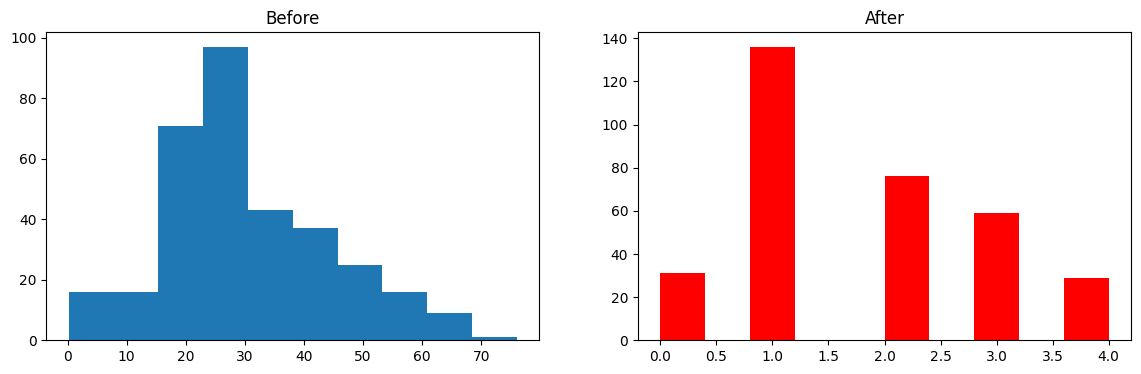

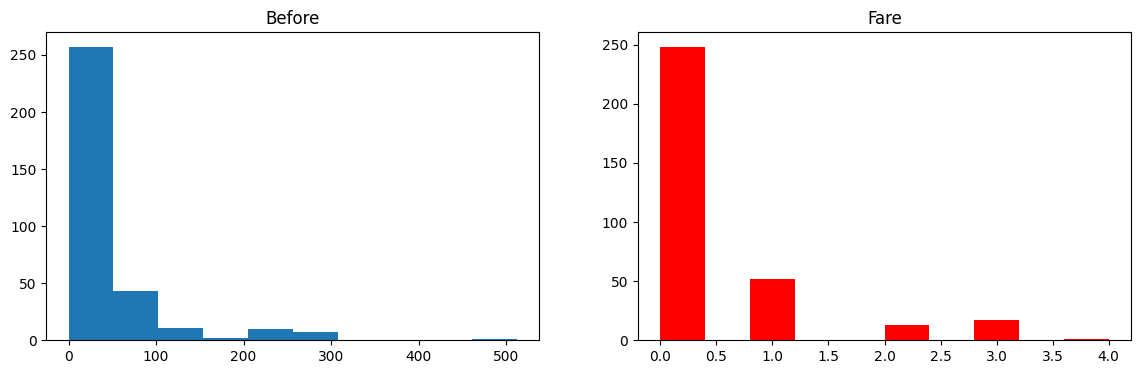

In [126]:
discretize(5,'kmeans')

# Binarization 


In [127]:
import numpy as np
import pandas as pd

In [128]:
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

from sklearn.compose import ColumnTransformer

In [130]:
df = pd.read_csv('E:\\WORK\\AI-ML\\data\\titanic.csv')[['Age','Fare','SibSp','Parch','Survived']]

In [132]:
df.dropna(inplace=True)

In [133]:
df.head()

,Age,Fare,SibSp,Parch,Survived
0,34.5,7.8292,0,0,0
1,47.0,7.0000,1,0,1
2,62.0,9.6875,0,0,0
3,27.0,8.6625,0,0,0
4,22.0,12.2875,1,1,1


In [134]:
df['family'] = df['SibSp'] + df['Parch']

In [135]:
df.head()

,Age,Fare,SibSp,Parch,Survived,family
0,34.5,7.8292,0,0,0,0
1,47.0,7.0000,1,0,1,1
2,62.0,9.6875,0,0,0,0
3,27.0,8.6625,0,0,0,0
4,22.0,12.2875,1,1,1,2


In [136]:
df.drop(columns=['SibSp','Parch'],inplace=True)

In [137]:
df.head()

,Age,Fare,Survived,family
0,34.5,7.8292,0,0
1,47.0,7.0000,1,1
2,62.0,9.6875,0,0
3,27.0,8.6625,0,0
4,22.0,12.2875,1,2


In [138]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [139]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [140]:
X_train.head()

,Age,Fare,family
281,0.75,13.7750,2
96,76.00,78.8500,1
341,32.00,7.5792,0
18,27.00,7.9250,1
26,22.00,61.9792,1


In [141]:
# Without binarization

clf = DecisionTreeClassifier()

clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

accuracy_score(y_test,y_pred)

0.6119402985074627

In [142]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.595276292335116)

In [143]:
# Applying Binarization

from sklearn.preprocessing import Binarizer

In [144]:
trf = ColumnTransformer([
    ('bin',Binarizer(copy=False),['family'])
],remainder='passthrough')

In [145]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [146]:
pd.DataFrame(X_train_trf,columns=['family','Age','Fare'])

,family,Age,Fare
0,1.0,0.75,13.7750
1,1.0,76.00,78.8500
2,0.0,32.00,7.5792
3,1.0,27.00,7.9250
4,1.0,22.00,61.9792
...,...,...,...
259,0.0,20.00,7.2250
260,0.0,27.00,7.8792
261,0.0,43.00,7.8958
262,0.0,16.00,7.6500


In [147]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

accuracy_score(y_test,y_pred2)

0.6119402985074627

In [148]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X_trf,y,cv=10,scoring='accuracy'))

np.float64(0.6102495543672014)